In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller
from scipy import stats
from scipy.special import inv_boxcox
import itertools

In [510]:
from pmdarima.arima import auto_arima
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.api import VAR
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [220]:
dataset_train = pd.read_csv('/home/pavel/Загрузки/archive/DailyDelhiClimateTrain.csv')

In [650]:
dataset_test = pd.read_csv('/home/pavel/Загрузки/archive/DailyDelhiClimateTest.csv')

In [7]:
dataset_train['date'] = pd.to_datetime(dataset_train['date'])

In [223]:
df_date = dataset_train.columns[0]
dataset_train = dataset_train.set_index(df_date)
dataset_train = dataset_train.dropna()

In [230]:
dataset_test

,date,meantemp,humidity,wind_speed,meanpressure
0,2017-01-01,15.913043,85.869565,2.743478,59.000000
1,2017-01-02,18.500000,77.222222,2.894444,1018.277778
2,2017-01-03,17.111111,81.888889,4.016667,1018.333333
3,2017-01-04,18.700000,70.050000,4.545000,1015.700000
4,2017-01-05,18.388889,74.944444,3.300000,1014.333333
...,...,...,...,...,...
109,2017-04-20,34.500000,27.500000,5.562500,998.625000
110,2017-04-21,34.250000,39.375000,6.962500,999.875000
111,2017-04-22,32.900000,40.900000,8.890000,1001.600000
112,2017-04-23,32.875000,27.500000,9.962500,1002.125000


In [224]:
dataset_train

,meantemp,humidity,wind_speed,meanpressure
date,,,,
2013-01-01,10.000000,84.500000,0.000000,1015.666667
2013-01-02,7.400000,92.000000,2.980000,1017.800000
2013-01-03,7.166667,87.000000,4.633333,1018.666667
2013-01-04,8.666667,71.333333,1.233333,1017.166667
2013-01-05,6.000000,86.833333,3.700000,1016.500000
...,...,...,...,...
2016-12-28,17.217391,68.043478,3.547826,1015.565217
2016-12-29,15.238095,87.857143,6.000000,1016.904762
2016-12-30,14.095238,89.666667,6.266667,1017.904762


In [225]:
columns_test_adfuller = ['meantemp', 'humidity', 'wind_speed', 'meanpressure']

In [664]:
def adfuller_test(dataset, features):
    dataset = dataset.copy()
    for feature in features:
        
        name_feature = dataset[feature].name
        result = adfuller(dataset[feature])
        print(f'Произведен тест Дики Фуллера фичи : {name_feature}')
        print('Результаты:\n')
        if result[1] > 0.05:
            print('Ряд не Стационарен, необходимо дифференцирование')
            print('\nДифференцирование...')
            dataset[feature] = dataset[feature].diff()
            dataset = dataset.dropna()
            result2 = adfuller(dataset[feature])
            print('Результат после дифференцирования')
            if result2[1] > 0.05:
                print('Ряд не стационарен')
                print(f'ADF статистика {result2[0]}')
                print(f'p-value = {result2[1]}')
                print('Нужно брать разность d == 2\n')
            else:
                print('Ряд стационарен')
                print(f'ADF статистика {result2[0]}')
                print(f'p-value = {result2[1]}')
                print('Нужно брать разность d == 1\n')
            
        else:
            print('Ряд стационарен. дифференцирование не нужно d == 0')
        print(f'ADF статистика {result[0]}')
        print(f'p-value = {result[1]}')
        print('Critical values:')
        for key, value in result[4].items():
            print('\t%s : %.3f\n'% (key, value))
    

In [227]:
adfuller_test(dataset_train, columns_test_adfuller)

Произведен тест Дики Фуллера фичи : meantemp
Результаты:

Ряд не Стационарен, необходимо дифференцирование

Дифференцирование...
Результат после дифференцирования
Ряд стационарен
ADF статистика -16.378720267074687
p-value = 2.764863137594565e-29
Нужно брать разность d == 1

ADF статистика -2.021069055920673
p-value = 0.2774121372301602
Critical values:
	1% : -3.435

	5% : -2.864

	10% : -2.568

Произведен тест Дики Фуллера фичи : humidity
Результаты:

Ряд стационарен. дифференцирование не нужно d == 0
ADF статистика -3.6637185251986617
p-value = 0.004653414494876207
Critical values:
	1% : -3.435

	5% : -2.864

	10% : -2.568

Произведен тест Дики Фуллера фичи : wind_speed
Результаты:

Ряд стационарен. дифференцирование не нужно d == 0
ADF статистика -3.820278653473789
p-value = 0.0027065205589752415
Critical values:
	1% : -3.435

	5% : -2.864

	10% : -2.568

Произведен тест Дики Фуллера фичи : meanpressure
Результаты:

Ряд стационарен. дифференцирование не нужно d == 0
ADF статистика -3

In [229]:
dataset_train = dataset_train.dropna()

In [667]:
arima_result = ARIMA(dataset_train['meantemp'], order=(1, 0, 1), trend= 'n')
arima_result_fit = arima_result.fit()

/home/pavel/ds-env/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/home/pavel/ds-env/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/home/pavel/ds-env/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


In [625]:
predicted_arima = arima_result.predict(1, len(dataset_train['meantemp']))

In [627]:
mae_arima = mean_absolute_error(predicted_arima,dataset_train['meantemp'] )
print(f'MAE ARIMA: {mae_arima:.4f}')

MAE ARIMA: 1.4959


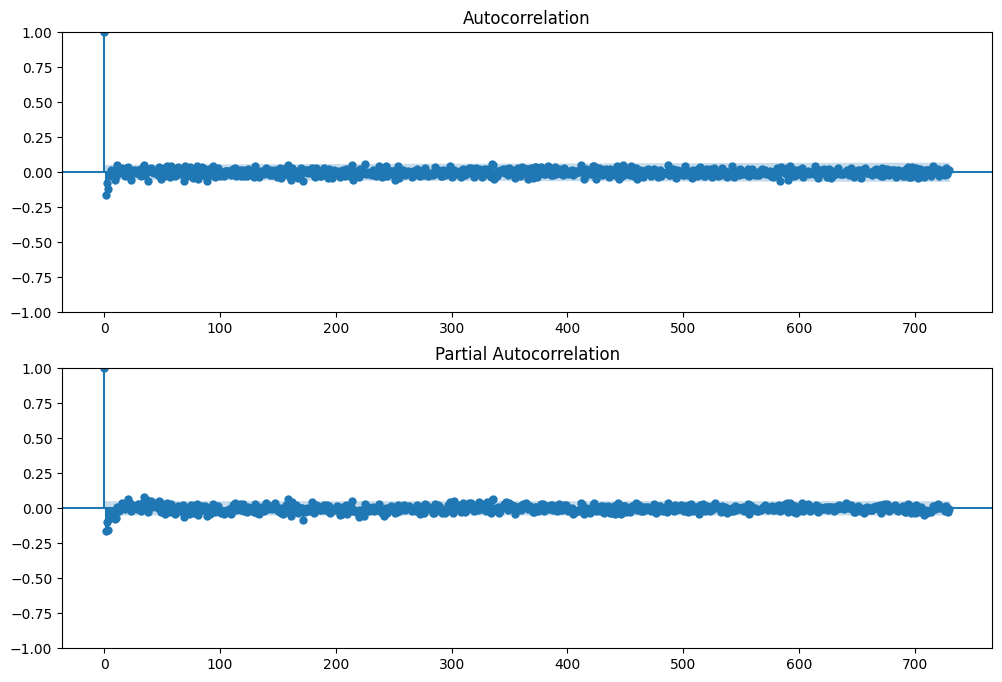

In [645]:
fig = plt.figure(figsize=(12,8))
ax1 = fig.add_subplot(211)
half_size = len(dataset_train['meantemp']) // 2
fig = plot_acf(dataset_train['meantemp'], lags=half_size, ax=ax1)
ax2 = fig.add_subplot(212)
fig = sm.graphics.tsa.plot_pacf(dataset_train['meantemp'], lags=half_size, ax=ax2)

In [629]:
model_predict_7 = arima_result.forecast(steps = 7)
model_predict_1 = arima_result.forecast(steps = 1)

In [409]:
full_act_val

np.float64(-5.052631578947368)

In [630]:
last_month = dataset_train['meantemp'][-32:]
full_train = dataset_train['meantemp'].copy()
full_act_val = dataset_train['meantemp'].values[-1]
full_act_idx = dataset_train['meantemp'].index[-1]
full_act_idx = pd.to_datetime(full_act_idx)
qfull_act_idx = dataset_train['meantemp'].index
qfull_act_val = dataset_train['meantemp'].values
qfull_act_idx = pd.to_datetime(qfull_act_idx)

In [631]:
pred_1_val = model_predict_1.values[0]
pred_1_idx = model_predict_1.index[0]
pred_7_val = model_predict_7.values[0]
pred_7_idx = model_predict_7.index[0]
act_val = last_month.values
act_idx = last_month.index
act_idx = pd.to_datetime(act_idx)
last_day = act_idx[-1]
last_val = act_val[-1]

In [611]:
pred_1_idx

Timestamp('2017-01-02 00:00:00')

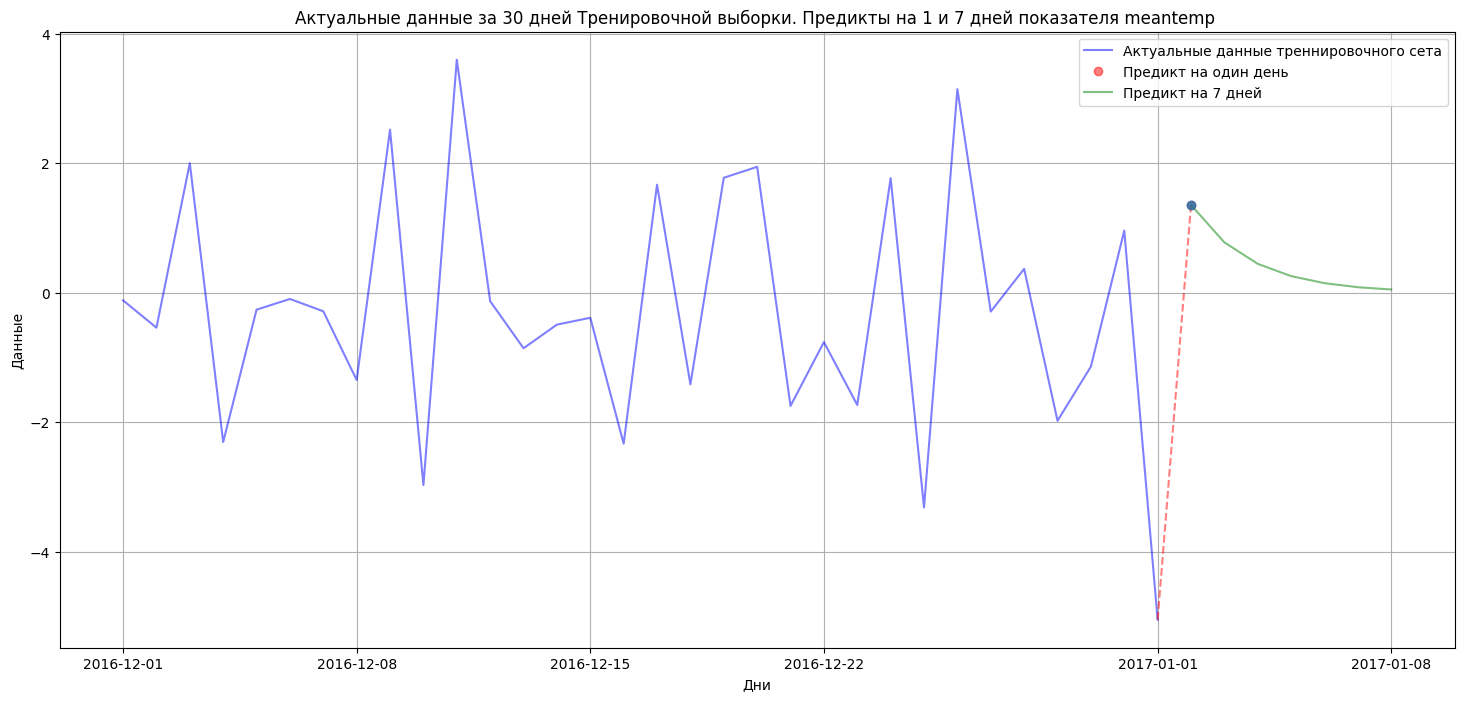

In [632]:
plt.figure(figsize = (18, 8))
plt.plot(act_idx, act_val ,'b', alpha = .5, label = 'Актуальные данные треннировочного сета')
plt.plot(pred_1_idx, pred_1_val ,'ro', alpha = .5, label = 'Предикт на один день')
plt.plot([last_day , pred_1_idx], [last_val, pred_1_val], 'r--', alpha = .5)
plt.plot(model_predict_7, 'g', alpha = .5, label = 'Предикт на 7 дней')
plt.plot([pred_1_idx , pred_7_idx], [pred_1_val, pred_7_val], 'o--', alpha = .5)
plt.title('Актуальные данные за 30 дней Тренировочной выборки. Предикты на 1 и 7 дней показателя meantemp ')
plt.xlabel('Дни')
plt.ylabel('Данные')
plt.legend(loc = 'upper right')
plt.grid()
plt.show()

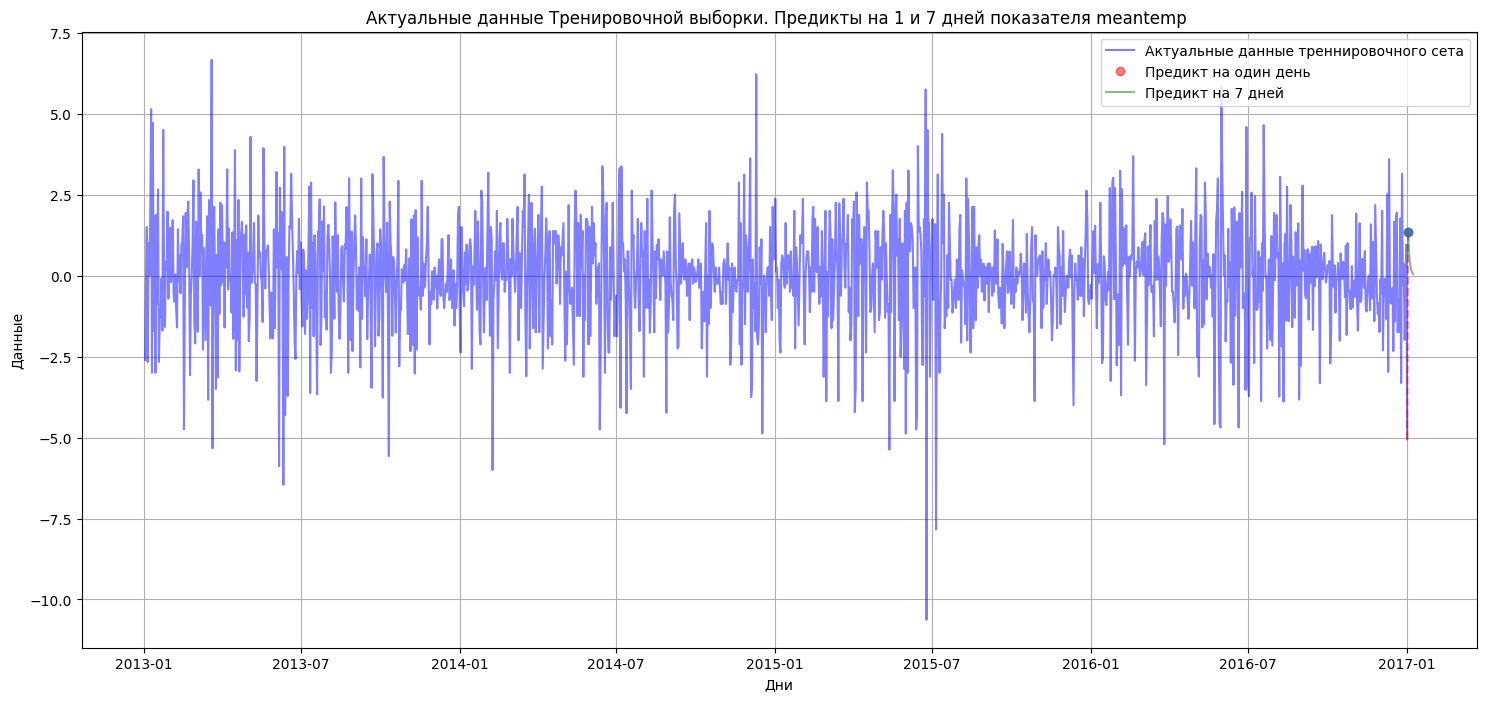

In [633]:
plt.figure(figsize = (18, 8))
plt.plot(qfull_act_idx, qfull_act_val, 'b', alpha = .5, label = 'Актуальные данные треннировочного сета')
plt.plot(pred_1_idx, pred_1_val ,'ro', alpha = .5, label = 'Предикт на один день')
plt.plot([full_act_idx , pred_1_idx], [full_act_val, pred_1_val], 'r--', alpha = .5)
plt.plot(model_predict_7, 'g', alpha = .5, label = 'Предикт на 7 дней')
plt.plot([pred_1_idx , pred_7_idx], [pred_1_val, pred_7_val], 'o--', alpha = .5)
plt.title('Актуальные данные Тренировочной выборки. Предикты на 1 и 7 дней показателя meantemp ')
plt.xlabel('Дни')
plt.ylabel('Данные')
plt.legend(loc = 'upper right')
plt.grid()
plt.show()

In [634]:
auto_arima_model = auto_arima(dataset_train['meantemp'], trace=True).fit(dataset_train['meantemp'])

Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0] intercept   : AIC=5546.314, Time=1.27 sec
 ARIMA(0,0,0)(0,0,0)[0] intercept   : AIC=5650.181, Time=0.04 sec
 ARIMA(1,0,0)(0,0,0)[0] intercept   : AIC=5614.068, Time=0.07 sec
 ARIMA(0,0,1)(0,0,0)[0] intercept   : AIC=5602.114, Time=0.08 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=5648.181, Time=0.02 sec
 ARIMA(1,0,2)(0,0,0)[0] intercept   : AIC=5546.168, Time=0.19 sec
 ARIMA(0,0,2)(0,0,0)[0] intercept   : AIC=5573.723, Time=0.15 sec
 ARIMA(1,0,1)(0,0,0)[0] intercept   : AIC=5544.460, Time=0.46 sec
 ARIMA(2,0,1)(0,0,0)[0] intercept   : AIC=5546.100, Time=0.45 sec
 ARIMA(2,0,0)(0,0,0)[0] intercept   : AIC=5600.849, Time=0.12 sec
 ARIMA(1,0,1)(0,0,0)[0]             : AIC=5542.478, Time=0.09 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=5600.115, Time=0.07 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=5612.068, Time=0.04 sec
 ARIMA(2,0,1)(0,0,0)[0]             : AIC=5544.118, Time=0.19 sec
 ARIMA(1,0,2)(0,0,0)[0]          

In [635]:
predict_auto_arima = auto_arima_model.predict()

In [636]:
pred_10_val = predict_auto_arima.values
pred_10_idx = predict_auto_arima.index
act_val = last_month.values
act_idx = last_month.index
act_idx = pd.to_datetime(act_idx)
last_day = act_idx[-1]
last_val = act_val[-1]

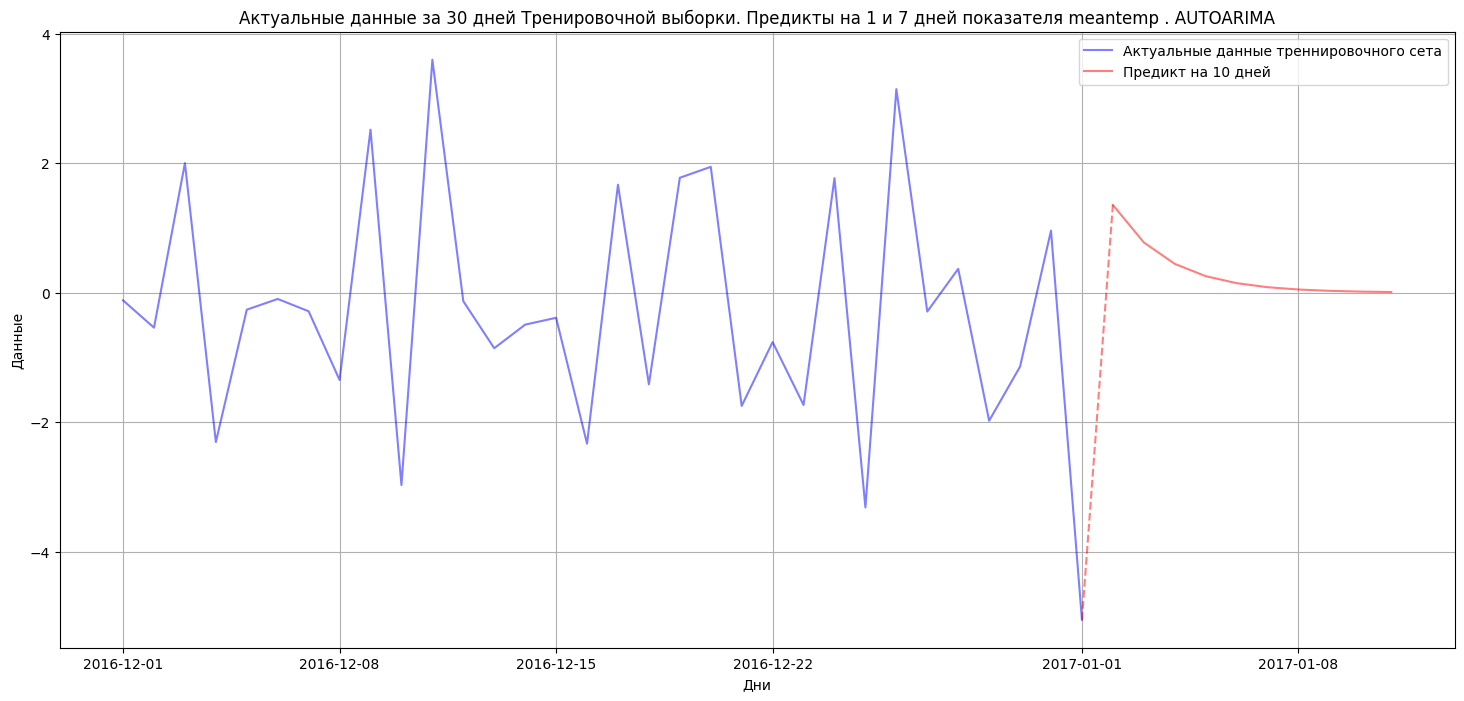

In [637]:
plt.figure(figsize = (18, 8))
plt.plot(act_idx, act_val ,'b', alpha = .5, label = 'Актуальные данные треннировочного сета')
plt.plot(pred_10_idx, pred_10_val ,'r', alpha = .5, label = 'Предикт на 10 дней')
plt.plot([last_day , pred_10_idx[0]], [last_val, pred_10_val[0]], 'r--', alpha = .5)
plt.title('Актуальные данные за 30 дней Тренировочной выборки. Предикты на 1 и 7 дней показателя meantemp . AUTOARIMA')
plt.xlabel('Дни')
plt.ylabel('Данные')
plt.legend(loc = 'upper right')
plt.grid()
plt.show()

In [638]:
model_sarima = SARIMAX(dataset_train['meantemp'], order=(1, 0, 1), seasonal_order=(0, 0, 0, 12))
model_sarima_fit = model_sarima.fit()

/home/pavel/ds-env/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/home/pavel/ds-env/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


In [640]:
model_sarima_fit.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:               meantemp   No. Observations:                 1461
Model:               SARIMAX(1, 0, 1)   Log Likelihood               -2768.239
Date:                Thu, 26 Mar 2026   AIC                           5542.478
Time:                        10:00:49   BIC                           5558.339
Sample:                    01-02-2013   HQIC                          5548.395
                         - 01-01-2017                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.5728      0.046     12.494      0.000       0.483       0.663
ma.L1         -0.8028      0.036    -22.070      0.000      -0.874      -0.731
sigma2         2.5896      0.072     36.204      0.000       2.449       2.730
===================================================================================
Ljung-Box (L1) (Q):                   0.09   Jarque-Bera (JB):               255.47
Prob(Q):                              0.76   Prob(JB):                         0.00
Heteroskedasticity (H):               0.80   Skew:                            -0.46
Prob(H) (two-sided):                  0.02   Kurtosis:                         4.83
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [641]:
predict_sarimax = model_sarima_fit.forecast(steps = 10)

In [642]:
pred_10_val_sarimax = predict_sarimax.values
pred_10_idx_sarimax = predict_sarimax.index
act_val = last_month.values
act_idx = last_month.index
act_idx = pd.to_datetime(act_idx)
last_day = act_idx[-1]
last_val = act_val[-1]

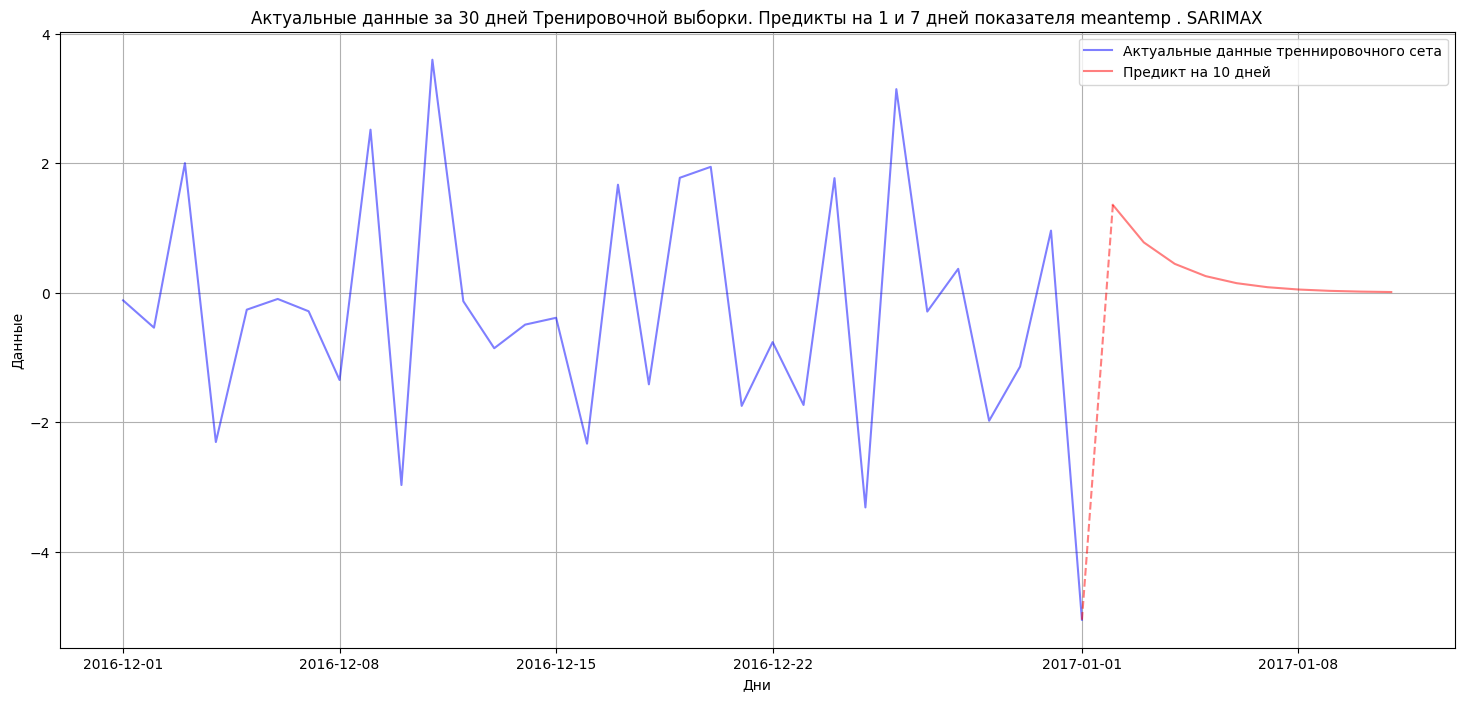

In [643]:
plt.figure(figsize = (18, 8))
plt.plot(act_idx, act_val ,'b', alpha = .5, label = 'Актуальные данные треннировочного сета')
plt.plot(pred_10_idx_sarimax, pred_10_val_sarimax ,'r', alpha = .5, label = 'Предикт на 10 дней')
plt.plot([last_day , pred_10_idx_sarimax[0]], [last_val, pred_10_val_sarimax[0]], 'r--', alpha = .5)
plt.title('Актуальные данные за 30 дней Тренировочной выборки. Предикты на 1 и 7 дней показателя meantemp . SARIMAX')
plt.xlabel('Дни')
plt.ylabel('Данные')
plt.legend(loc = 'upper right')
plt.grid()
plt.show()

In [533]:
model_var = VAR(dataset_train)
model_var_fit = model_var.fit(1)

/home/pavel/ds-env/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


In [534]:
model_var_fit.summary()

  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Wed, 25, Mar, 2026
Time:                     23:11:42
--------------------------------------------------------------------
No. of Equations:         4.00000    BIC:                    17.7827
Nobs:                     1460.00    HQIC:                   17.7373
Log likelihood:          -21195.1    FPE:                4.91426e+07
AIC:                      17.7102    Det(Omega_mle):     4.84751e+07
--------------------------------------------------------------------
Results for equation meantemp
                     coefficient       std. error           t-stat            prob
----------------------------------------------------------------------------------
const                  -0.506097         0.323545           -1.564           0.118
L1.meantemp            -0.146389         0.026388           -5.548           0.000
L1.humidity             0.007891         0.002830

In [564]:
p = model_var_fit.k_ar
last_observations = dataset_train[model_var_fit.names].iloc[-p:].values
model_var_predict = model_var_fit.forecast(y=last_observations, steps=10)

print("Предикт на 10 дней:")
print(model_var_predict)

Предикт на 10 дней:
[[1.19256669e+00 9.23079539e+01 2.27827619e+00 1.00426208e+03]
 [1.68878500e-01 8.95808138e+01 3.69635688e+00 1.01589925e+03]
 [2.70032070e-01 8.65468770e+01 4.31780237e+00 1.01341594e+03]
 [2.18102789e-01 8.39286850e+01 4.69345511e+00 1.01333255e+03]
 [1.97314069e-01 8.15677646e+01 4.95303780e+00 1.01302625e+03]
 [1.76343809e-01 7.94510735e+01 5.15843084e+00 1.01282102e+03]
 [1.58457377e-01 7.75501243e+01 5.33229467e+00 1.01263923e+03]
 [1.42473504e-01 7.58428957e+01 5.48451420e+00 1.01248046e+03]
 [1.28188227e-01 7.43094562e+01 5.61975846e+00 1.01233901e+03]
 [1.15377260e-01 7.29320703e+01 5.74068534e+00 1.01221247e+03]]


In [ ]:
#сделат предсказание на все 4 значения на один день и на несколько (это вообще если получится хотя бы на один)

In [ ]:
metodi podbora / predict